1. Import Libraries


In [ ]:
import pandas as pd
data = pd.read_csv('hotel_bookings.csv')

2. Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

3. Data Loading and Cleaning

In [ ]:

hotel_bookings = pd.read_csv('hotel_bookings.csv')


print(hotel_bookings.head())


print("Null values:\n", hotel_bookings.isnull().sum())


hotel_bookings = hotel_bookings.dropna()

print("Duplicate rows:", hotel_bookings.duplicated().sum())
hotel_bookings = hotel_bookings.drop_duplicates()

print("Dataset shape after cleaning:", hotel_bookings.shape)


          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

4. One-Hot Encoding

In [ ]:

data = pd.get_dummies(data, columns=['hotel', 'meal', 'market_segment'], drop_first=True)


5. Feature and Target Definition

In [ ]:
from sklearn.model_selection import train_test_split


X = data[['lead_time', 'adults', 'children', 'previous_cancellations']]
y = data['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


6. Logistic Regression Model

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

7. Model Evaluation: Logistic Regression

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred = logreg.predict(X_test)

# Metrics
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93        50
           1       0.00      0.00      0.00         7

    accuracy                           0.88        57
   macro avg       0.44      0.50      0.47        57
weighted avg       0.77      0.88      0.82        57

[[50  0]
 [ 7  0]]
ROC AUC: 0.47285714285714275


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


8. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

9. Model Evaluation: Decision Tree

In [ ]:
# Predictions
y_pred_tree = dtree.predict(X_test)

# Metrics
print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print("ROC AUC:", roc_auc_score(y_test, dtree.predict_proba(X_test)[:, 1]))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93        50
           1       0.00      0.00      0.00         7

    accuracy                           0.88        57
   macro avg       0.44      0.50      0.47        57
weighted avg       0.77      0.88      0.82        57

[[50  0]
 [ 7  0]]
ROC AUC: 0.5857142857142856


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


10. Visualizing Decision Tree

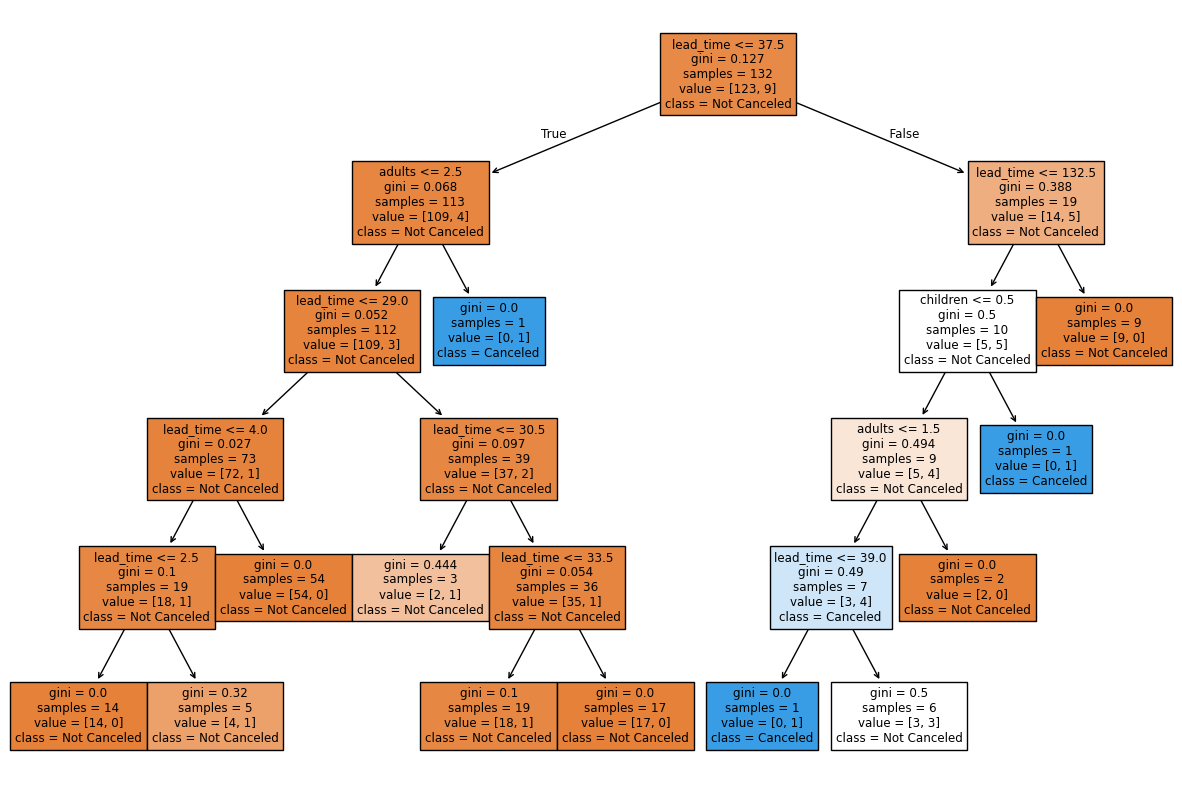

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(dtree, feature_names=X.columns, class_names=['Not Canceled', 'Canceled'], filled=True)
plt.show()


11. Feature Importance

In [ ]:

importance = pd.DataFrame({'Feature': X.columns, 'Importance': dtree.feature_importances_})
importance = importance.sort_values('Importance', ascending=False)
print(importance)


                  Feature  Importance
0               lead_time    0.614411
1                  adults    0.323478
2                children    0.062110
3  previous_cancellations    0.000000


12. Hyperparameter Tuning

In [ ]:
from sklearn.utils import resample

majority = hotel_bookings[hotel_bookings['is_canceled'] == 0]
minority = hotel_bookings[hotel_bookings['is_canceled'] == 1]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
hotel_bookings = pd.concat([majority, minority_upsampled])


13. Random Forest for model comparison

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        50
           1       0.50      0.14      0.22         7

    accuracy                           0.88        57
   macro avg       0.70      0.56      0.58        57
weighted avg       0.84      0.88      0.85        57

ROC AUC: 0.6385714285714286


14. ROC Curve

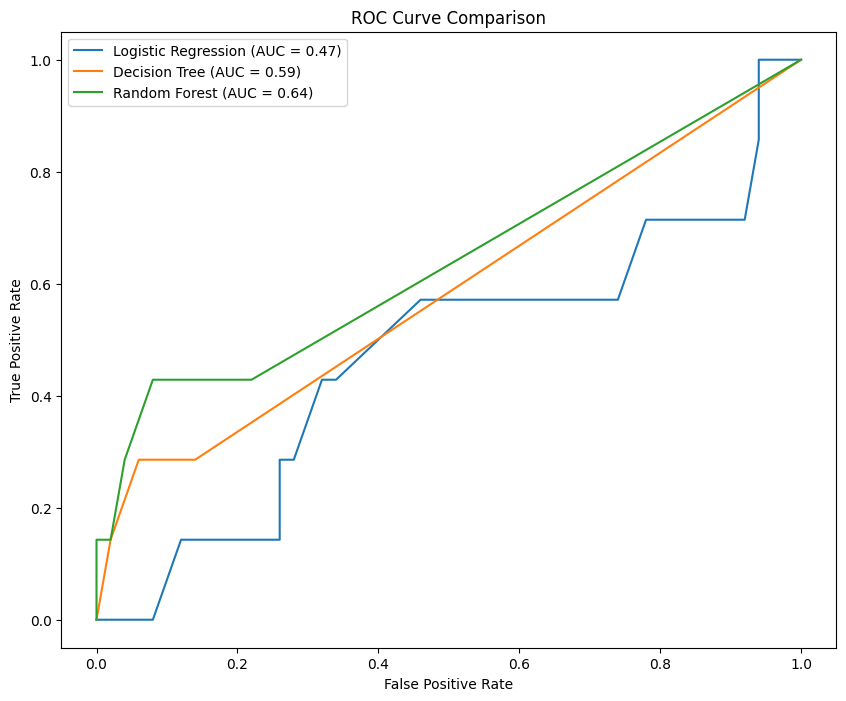

In [ ]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves
plt.figure(figsize=(10, 8))
for model, label in [(logreg, "Logistic Regression"), (dtree, "Decision Tree"), (rf, "Random Forest")]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


15. Seasonality in Cancellations

<ipython-input-51-1fb3f28770af>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=hotel_bookings, x='arrival_date_month', y='is_canceled', ci=None)


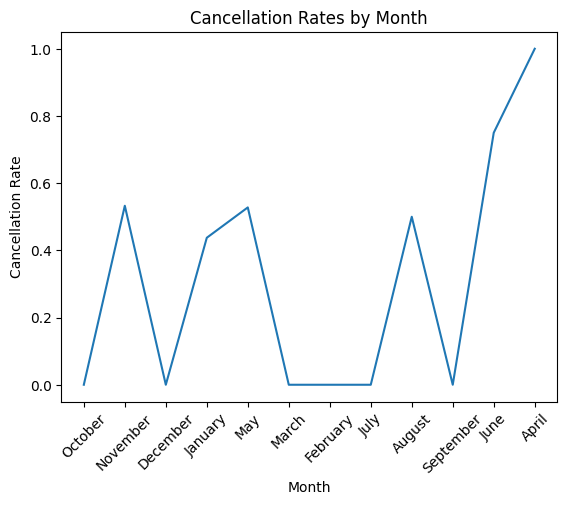

In [ ]:
sns.lineplot(data=hotel_bookings, x='arrival_date_month', y='is_canceled', ci=None)
plt.title('Cancellation Rates by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.show()


16.Lead Time Distribution

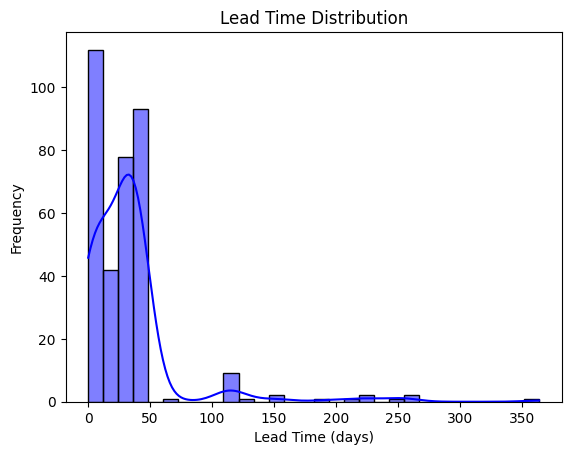

In [ ]:
sns.histplot(hotel_bookings['lead_time'], bins=30, kde=True, color='blue')
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.show()
